# Applied Massive Parallelism: CUDA Python
**Student:** Aibek Ayazgaliyev  
**Student ID:** 230103341  
**Session:** Lecture  
**Date / start time:** 08.10.2026 11:30

The user approved execution on the local physical NVIDIA RTX4060 instead of the PDF's assigned Colab T4. Run all cells in order and retain outputs; this is not a Colab completion claim. Measurements and the token must come from the real GPU, not simulation. The final cell writes TASK_SHEET.md, raw JSON results, and the CSV benchmark to the current working directory.

## Section 1. Environment and Hardware (15 min)


In [1]:
!nvidia-smi


Thu Oct  8 12:44:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 610.88                 KMD Version: 610.88        CUDA UMD Version: 13.3     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4060 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   45C    P8              4W /   35W |       0MiB /   8188MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
from numba import cuda
import subprocess
import re

STUDENT_ID = '230103341'
STUDENT_NAME = 'Aibek Ayazgaliyev'
SESSION = 'Lecture'
SESSION_DATE = '08.10.2026 11:30'
if cuda.config.ENABLE_CUDASIM:
    raise RuntimeError('CUDA simulation is not valid for empirical lab results.')
if not cuda.is_available():
    raise RuntimeError('A working local CUDA GPU and driver are required.')
cuda.select_device(0)
device = cuda.get_current_device()
gpu_name = device.name.decode('utf-8') if isinstance(device.name, bytes) else device.name
print(f'Device Name: {gpu_name}')
print(f'Compute Capability: {device.compute_capability}')
print(f'Multiprocessor Count (SMs): {device.MULTIPROCESSOR_COUNT}')
print(f'Max Threads Per Block: {device.MAX_THREADS_PER_BLOCK}')
print(f'Max Block Dimensions: {device.MAX_BLOCK_DIM_X}, {device.MAX_BLOCK_DIM_Y}, {device.MAX_BLOCK_DIM_Z}')
print(f'Warp Size: {device.WARP_SIZE}')
smi_output = subprocess.check_output(['nvidia-smi'], text=True)
query = subprocess.check_output([
    'nvidia-smi', '--id=0',
    '--query-gpu=index,uuid,name,driver_version,memory.total',
    '--format=csv,noheader,nounits',
], text=True).strip().split(',')
gpu_index, gpu_uuid, smi_name, driver_version, vram_mib = [value.strip() for value in query]
cuda_version_match = re.search(r'CUDA(?: UMD)? Version:\s*([0-9.]+)', smi_output)
if cuda_version_match is None:
    raise RuntimeError('Cannot extract driver-supported CUDA version from nvidia-smi.')
telemetry = {
    'gpu_index': gpu_index, 'gpu_uuid': gpu_uuid, 'gpu_name': gpu_name,
    'driver_version': driver_version, 'cuda_version': cuda_version_match.group(1),
    'vram_mib': int(vram_mib),
    'compute_capability': '.'.join(map(str, device.compute_capability)),
    'multiprocessors': device.MULTIPROCESSOR_COUNT,
    'max_threads_per_block': device.MAX_THREADS_PER_BLOCK, 'warp_size': device.WARP_SIZE,
}
for key, value in telemetry.items():
    print(f'{key}: {value}')


Device Name: NVIDIA GeForce RTX 4060 Laptop GPU
Compute Capability: ComputeCapability(major=8, minor=9)
Multiprocessor Count (SMs): 24
Max Threads Per Block: 1024
Max Block Dimensions: 1024, 1024, 64
Warp Size: 32
gpu_index: 0
gpu_uuid: GPU-0c13a78b-5a3e-7434-f187-59658df572e9
gpu_name: NVIDIA GeForce RTX 4060 Laptop GPU
driver_version: 610.88
cuda_version: 13.3
vram_mib: 8188
compute_capability: 8.9
multiprocessors: 24
max_threads_per_block: 1024
warp_size: 32


## Section 2. Vector Doubling and Crossover (25 min)
Use np.random.seed(230103341) and np.random.rand with float32 inputs. Measure the pure Python CPU loop at every size, including sizes the PDF permits skipping, to fill every row. Warm up compilation before timing. Both GPU measurements use synchronized perf_counter timing: total roundtrip includes allocation and both transfers; kernel-only uses preloaded arrays and includes launch/synchronization overhead. Winner compares CPU against GPU total.


In [3]:
import numpy as np
import time

def double_cpu_pure(arr):
    out = np.empty_like(arr)
    for i in range(len(arr)):
        out[i] = arr[i] * 2.0
    return out

@cuda.jit
def double_gpu_kernel(d_in, d_out):
    idx = cuda.grid(1)
    if idx < d_in.shape[0]:
        d_out[idx] = d_in[idx] * 2.0

def benchmark_run(N, student_id_seed=int(STUDENT_ID)):
    np.random.seed(student_id_seed)
    h_in = np.random.rand(N).astype(np.float32)
    t0 = time.perf_counter()
    cpu_out = double_cpu_pure(h_in)
    cpu_time_ms = (time.perf_counter() - t0) * 1000.0
    np.testing.assert_array_equal(cpu_out, h_in * np.float32(2.0))
    threads_per_block = 256
    blocks_per_grid = (N + threads_per_block - 1) // threads_per_block
    d_warmup = cuda.to_device(np.ones(10, dtype=np.float32))
    double_gpu_kernel[1, 32](d_warmup, d_warmup)
    cuda.synchronize()
    t0 = time.perf_counter()
    d_in = cuda.to_device(h_in)
    d_out = cuda.device_array_like(d_in)
    double_gpu_kernel[blocks_per_grid, threads_per_block](d_in, d_out)
    h_out = d_out.copy_to_host()
    cuda.synchronize()
    gpu_total_ms = (time.perf_counter() - t0) * 1000.0
    np.testing.assert_array_equal(h_out, h_in * np.float32(2.0))
    t0 = time.perf_counter()
    double_gpu_kernel[blocks_per_grid, threads_per_block](d_in, d_out)
    cuda.synchronize()
    gpu_kernel_ms = (time.perf_counter() - t0) * 1000.0
    return {
        'N': N, 'cpu_ms': cpu_time_ms, 'gpu_total_ms': gpu_total_ms,
        'gpu_kernel_ms': gpu_kernel_ms,
        'winner': (
            'GPU' if gpu_total_ms < cpu_time_ms else 'CPU' if cpu_time_ms < gpu_total_ms else 'Tie'),
    }

sizes = [100, 1_000, 10_000, 100_000, 1_000_000, 5_000_000, 10_000_000]
benchmark_rows = [benchmark_run(N) for N in sizes]
print(f"{'N':>10} | {'CPU ms':>12} | {'GPU total ms':>12} | {'GPU kernel only ms':>18} | Winner")
for row in benchmark_rows:
    print(f"{row['N']:>10} | {row['cpu_ms']:>12.6f} | {row['gpu_total_ms']:>12.6f} | {row['gpu_kernel_ms']:>18.6f} | {row['winner']}")
CROSSOVER_N = next((row['N'] for row in benchmark_rows if row['winner'] == 'GPU'), None)
q1 = (f'The first tested size at which GPU total beats CPU is N* = {CROSSOVER_N:,}.'
      if CROSSOVER_N is not None else 'No crossover observed among sizes with measured CPU times.')
small = benchmark_rows[0]
non_kernel_fraction = 100.0 * (small['gpu_total_ms'] - small['gpu_kernel_ms']) / small['gpu_total_ms']
q2 = (f"At N=100, GPU total is {small['gpu_total_ms']:.6f} ms, versus kernel {small['gpu_kernel_ms']:.6f} ms. "
      f'The difference is approximately {non_kernel_fraction:.2f}% of total time. '
      'Allocation, PCIe transfers, launch, and synchronization can dominate tiny workloads; '
      'these separately sampled intervals do not isolate PCIe time or guarantee a 95% overhead fraction.')
print('Q1:', q1)
print('Q2:', q2)


C:\Users\aiblb\AppData\Local\Temp\opencode\cuda-230103341\Lib\site-packages\numba_cuda\numba\cuda\dispatcher.py:748: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


C:\Users\aiblb\AppData\Local\Temp\opencode\cuda-230103341\Lib\site-packages\numba_cuda\numba\cuda\dispatcher.py:748: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
C:\Users\aiblb\AppData\Local\Temp\opencode\cuda-230103341\Lib\site-packages\numba_cuda\numba\cuda\dispatcher.py:748: NumbaPerformanceWarning: Grid size 4 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
C:\Users\aiblb\AppData\Local\Temp\opencode\cuda-230103341\Lib\site-packages\numba_cuda\numba\cuda\dispatcher.py:748: NumbaPerformanceWarning: Grid size 40 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


         N |       CPU ms | GPU total ms | GPU kernel only ms | Winner
       100 |     0.045700 |     2.138000 |           0.134300 | CPU
      1000 |     0.245000 |     0.974000 |           0.165500 | CPU
     10000 |     3.668100 |     1.165500 |           0.190700 | GPU
    100000 |    30.719000 |     1.004000 |           0.144300 | GPU
   1000000 |   295.895400 |     3.320900 |           0.375000 | GPU
   5000000 |  1513.191400 |    11.936000 |           0.504400 | GPU
  10000000 |  2868.926800 |    19.743300 |           4.137800 | GPU
Q1: The first tested size at which GPU total beats CPU is N* = 10,000.
Q2: At N=100, GPU total is 2.138000 ms, versus kernel 0.134300 ms. The difference is approximately 93.72% of total time. Allocation, PCIe transfers, launch, and synchronization can dominate tiny workloads; these separately sampled intervals do not isolate PCIe time or guarantee a 95% overhead fraction.


## Section 3. Thread Geometry and Missing Guard (25 min)
### Task 3.1. Deliberately Unsafe Kernel
For N=1000, ceil(1000/256)=4 blocks launch 1024 threads, including 24 out-of-bounds writers. The intentionally defective experiment runs in a **separate process on GPU 0**, the same local physical GPU, to isolate its CUDA context. It may silently corrupt memory or raise an asynchronous error; a successful host copy does not establish memory safety. Capture stdout and stderr with a 120-second timeout.


In [4]:
import sys

defective_source = '''
from numba import cuda
import numpy as np
cuda.select_device(0)
print(f'Defective experiment GPU: {cuda.get_current_device().name}', flush=True)
@cuda.jit
def defective_kernel(d_arr):
    idx = cuda.grid(1)
    d_arr[idx] = 999.0
N = 1000
d_arr = cuda.to_device(np.zeros(N, dtype=np.float32))
print('Launching defective kernel with 1024 threads on 1000-element array...', flush=True)
defective_kernel[4, 256](d_arr)
cuda.synchronize()
print('Execution finished (or did it crash?). Checking host copy...', flush=True)
h_result = d_arr.copy_to_host()
print(f'Elements processed: {len(h_result)}. Last element: {h_result[-1]}', flush=True)
'''
try:
    defective_run = subprocess.run(
        [sys.executable, '-u', '-c', defective_source],
        stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, timeout=120,
    )
    defective_observation = f'Child exit code: {defective_run.returncode}\n{defective_run.stdout}'
except subprocess.TimeoutExpired as exc:
    captured = exc.stdout or b''
    if isinstance(captured, bytes):
        captured = captured.decode('utf-8', errors='replace')
    defective_observation = f'Child timed out after 120 seconds.\n{captured}'
print(defective_observation)
cuda.synchronize()


Child exit code: 0
Defective experiment GPU: NVIDIA GeForce RTX 4060 Laptop GPU
Launching defective kernel with 1024 threads on 1000-element array...
C:\Users\aiblb\AppData\Local\Temp\opencode\cuda-230103341\Lib\site-packages\numba_cuda\numba\cuda\dispatcher.py:748: NumbaPerformanceWarning: Grid size 4 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
Execution finished (or did it crash?). Checking host copy...
Elements processed: 1000. Last element: 999.0



### Task 3.2. Spatial Thread Inspector
N=37 and block size 8 give 5 blocks, 40 launched threads, 37 active threads, and 3 guarded idle threads. Copy log buffers to the host before printing.


In [5]:
@cuda.jit
def inspect_threads_kernel(log_block, log_thread, log_global, log_active, N):
    t_idx = cuda.threadIdx.x
    b_idx = cuda.blockIdx.x
    g_idx = cuda.grid(1)
    if g_idx < log_block.shape[0]:
        log_block[g_idx] = b_idx
        log_thread[g_idx] = t_idx
        log_global[g_idx] = g_idx
        log_active[g_idx] = 1 if g_idx < N else 0

N = 37
threads_per_block = 8
blocks_per_grid = (N + threads_per_block - 1) // threads_per_block
launched = blocks_per_grid * threads_per_block
log_b = cuda.device_array(launched, dtype=np.int32)
log_t = cuda.device_array(launched, dtype=np.int32)
log_g = cuda.device_array(launched, dtype=np.int32)
log_a = cuda.device_array(launched, dtype=np.int32)
inspect_threads_kernel[blocks_per_grid, threads_per_block](log_b, log_t, log_g, log_a, N)
cuda.synchronize()
host_b, host_t, host_g, host_a = [log.copy_to_host() for log in (log_b, log_t, log_g, log_a)]
np.testing.assert_array_equal(host_g, np.arange(launched))
np.testing.assert_array_equal(host_b, np.arange(launched) // threads_per_block)
np.testing.assert_array_equal(host_t, np.arange(launched) % threads_per_block)
np.testing.assert_array_equal(host_a, (np.arange(launched) < N).astype(np.int32))
thread_geometry = {'blocks': blocks_per_grid, 'launched': launched,
                   'active': int(host_a.sum()), 'idle': int(launched - host_a.sum())}
boundary_rows = []
print(f"{'Global ID':<10} | {'Block ID':<10} | {'Thread ID':<10} | Status")
for i in range(32, 40):
    status = 'ACTIVE' if host_a[i] == 1 else 'IDLE (GUARDED)'
    boundary_rows.append([int(host_g[i]), int(host_b[i]), int(host_t[i]), status])
    print(f'{host_g[i]:<10} | {host_b[i]:<10} | {host_t[i]:<10} | {status}')
print(thread_geometry)


Global ID  | Block ID   | Thread ID  | Status
32         | 4          | 0          | ACTIVE
33         | 4          | 1          | ACTIVE
34         | 4          | 2          | ACTIVE
35         | 4          | 3          | ACTIVE
36         | 4          | 4          | ACTIVE
37         | 4          | 5          | IDLE (GUARDED)
38         | 4          | 6          | IDLE (GUARDED)
39         | 4          | 7          | IDLE (GUARDED)
{'blocks': 5, 'launched': 40, 'active': 37, 'idle': 3}


C:\Users\aiblb\AppData\Local\Temp\opencode\cuda-230103341\Lib\site-packages\numba_cuda\numba\cuda\dispatcher.py:748: NumbaPerformanceWarning: Grid size 5 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


## Section 4. Race Conditions and Atomic Reduction (25 min)
Use the mandatory table's 50,000 ones. Reset the accumulator before every launch and warm up both kernels. Synchronized perf_counter timings exclude transfers and compilation. Run five trials of each kernel; identical naive outputs do not establish correctness. The float32 atomic sum should be exactly 50,000.


In [6]:
@cuda.jit
def naive_sum_kernel(d_arr, d_total):
    idx = cuda.grid(1)
    if idx < d_arr.shape[0]:
        d_total[0] += d_arr[idx]

@cuda.jit
def atomic_sum_kernel(d_arr, d_total):
    idx = cuda.grid(1)
    if idx < d_arr.shape[0]:
        cuda.atomic.add(d_total, 0, d_arr[idx])

sum_N = 50_000
sum_threads = 256
sum_blocks = (sum_N + sum_threads - 1) // sum_threads
d_ones = cuda.to_device(np.ones(sum_N, dtype=np.float32))
zero = np.zeros(1, dtype=np.float32)
d_total = cuda.to_device(zero)
for kernel in (naive_sum_kernel, atomic_sum_kernel):
    d_total.copy_to_device(zero)
    kernel[sum_blocks, sum_threads](d_ones, d_total)
    cuda.synchronize()

def reduction_trial(kernel):
    d_total.copy_to_device(zero)
    cuda.synchronize()
    t0 = time.perf_counter()
    kernel[sum_blocks, sum_threads](d_ones, d_total)
    cuda.synchronize()
    elapsed_ms = (time.perf_counter() - t0) * 1000.0
    return float(d_total.copy_to_host()[0]), float(elapsed_ms)

naive_trials = []
print('Trial | Target sum | Naive output | Lost updates | Kernel ms')
for trial in range(1, 6):
    value, elapsed_ms = reduction_trial(naive_sum_kernel)
    naive_trials.append({'trial': trial, 'target': float(sum_N), 'output': value,
                         'lost_updates': float(sum_N) - value, 'kernel_ms': elapsed_ms})
    print(f'{trial} | {sum_N:.1f} | {value:.1f} | {sum_N - value:.1f} | {elapsed_ms:.6f}')
atomic_trials = [reduction_trial(atomic_sum_kernel) for _ in range(5)]
assert all(value == float(sum_N) for value, _ in atomic_trials), 'Atomic sum mismatch'
atomic_output = atomic_trials[-1][0]
naive_ms = float(np.median([row['kernel_ms'] for row in naive_trials]))
atomic_ms = float(np.median([elapsed for _, elapsed in atomic_trials]))
atomic_ratio = atomic_ms / naive_ms if naive_ms > 0 else None
atomic_explanation = (
    'Atomic addition prevents lost read-modify-write updates. All threads contend for the same '
    'scalar address, so updates are serialized rather than proceeding independently. '
    'The actual penalty depends on hardware, compiler optimizations, and timing noise; '
    'an incorrect naive result is not an equivalent correct algorithm.'
)
print(f'Atomic output: {atomic_output}; exactly 50000.0: {atomic_output == 50000.0}')
print(f'Median of 5 trials: naive {naive_ms:.6f} ms; atomic {atomic_ms:.6f} ms; atomic/naive ratio: {atomic_ratio}')
print(atomic_explanation)


Trial | Target sum | Naive output | Lost updates | Kernel ms
1 | 50000.0 | 2.0 | 49998.0 | 0.120800
2 | 50000.0 | 2.0 | 49998.0 | 0.090200
3 | 50000.0 | 2.0 | 49998.0 | 0.078000
4 | 50000.0 | 2.0 | 49998.0 | 0.077800
5 | 50000.0 | 2.0 | 49998.0 | 0.075900


Atomic output: 50000.0; exactly 50000.0: True
Median of 5 trials: naive 0.078000 ms; atomic 0.154700 ms; atomic/naive ratio: 1.983333207403305
Atomic addition prevents lost read-modify-write updates. All threads contend for the same scalar address, so updates are serialized rather than proceeding independently. The actual penalty depends on hardware, compiler optimizations, and timing noise; an incorrect naive result is not an equivalent correct algorithm.


## Section 5. 2D Radial Vignette (20 min)
A 1024 x 1024 canvas with 16 x 16 blocks uses a 64 x 64 grid: 4096 blocks and 1,048,576 threads. Verify the GPU output against a NumPy reference, including center and outer corner.


Generated 2D matrix shape: (1024, 1024). Center value: 1.000
{'blocks_x': 64, 'blocks_y': 64, 'total_blocks': 4096, 'center_value': 1.0, 'corner_value': 0.0}


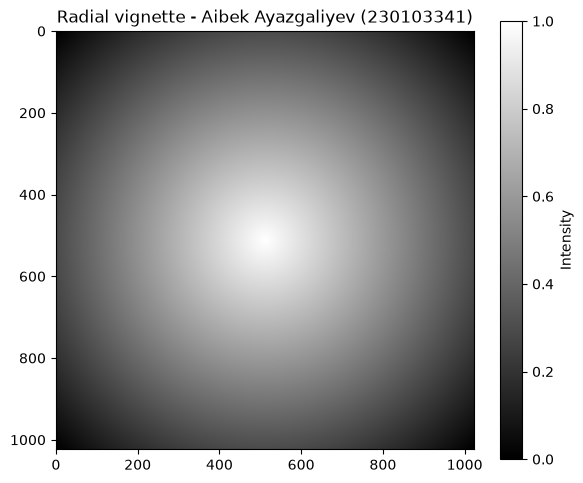

In [7]:
import math

@cuda.jit
def radial_vignette_2d(d_canvas, width, height, center_x, center_y):
    x, y = cuda.grid(2)
    if x < width and y < height:
        dx = float(x - center_x)
        dy = float(y - center_y)
        dist = math.sqrt(dx * dx + dy * dy)
        max_dist = math.sqrt(float(center_x**2 + center_y**2))
        intensity = 1.0 - dist / max_dist
        if intensity < 0.0:
            intensity = 0.0
        d_canvas[y, x] = intensity

WIDTH, HEIGHT = 1024, 1024
canvas = np.zeros((HEIGHT, WIDTH), dtype=np.float32)
d_canvas = cuda.to_device(canvas)
threads_2d = (16, 16)
blocks_2d = ((WIDTH + threads_2d[0] - 1) // threads_2d[0],
             (HEIGHT + threads_2d[1] - 1) // threads_2d[1])
radial_vignette_2d[blocks_2d, threads_2d](d_canvas, WIDTH, HEIGHT, WIDTH // 2, HEIGHT // 2)
cuda.synchronize()
result_canvas = d_canvas.copy_to_host()
yy, xx = np.indices((HEIGHT, WIDTH))
reference = np.maximum(0.0, 1.0 - np.sqrt((xx - WIDTH // 2)**2 + (yy - HEIGHT // 2)**2)
                       / math.sqrt((WIDTH // 2)**2 + (HEIGHT // 2)**2)).astype(np.float32)
np.testing.assert_allclose(result_canvas, reference, rtol=1e-5, atol=1e-6)
center_value = float(result_canvas[512, 512])
corner_value = float(result_canvas[0, 0])
assert center_value == 1.0
assert abs(corner_value) <= 1e-6
image_geometry = {'blocks_x': blocks_2d[0], 'blocks_y': blocks_2d[1],
                  'total_blocks': blocks_2d[0] * blocks_2d[1],
                  'center_value': center_value, 'corner_value': corner_value}
print(f'Generated 2D matrix shape: {result_canvas.shape}. Center value: {center_value:.3f}')
print(image_geometry)
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 5))
plt.imshow(result_canvas, cmap='gray', vmin=0, vmax=1)
plt.colorbar(label='Intensity')
plt.title(f'Radial vignette - {STUDENT_NAME} ({STUDENT_ID})')
plt.tight_layout()
plt.show()


## Section 6. Official Checksum and Task Sheet (10 min)
The function below follows the supplied SHA-256 algorithm exactly, using this student's ID, the physical GPU name, the top-left 10 x 10 output sample, and the measured crossover. If no crossover was observed, the value is `None`, not an invented example. The token binds these inputs; a hash alone does not prove execution or prevent fabrication.

Run this final cell locally to generate the three artifacts. Retain the executed notebook's outputs, review TASK_SHEET.md, and complete the unchecked submission steps.


In [8]:
import hashlib
import json
import csv
from pathlib import Path
from IPython.display import Markdown, display

def generate_lab_checksum(student_id_str, d_canvas, exp_table_crossover):
    h = hashlib.sha256()
    h.update(student_id_str.strip().encode('utf-8'))
    name = cuda.get_current_device().name
    h.update(name if isinstance(name, bytes) else name.encode('utf-8'))
    h.update(d_canvas.copy_to_host()[:10, :10].tobytes())
    h.update(str(exp_table_crossover).encode('utf-8'))
    digest = h.hexdigest()[:16].upper()
    print('=' * 60)
    print(f'OFFICIAL VERIFICATION CHECKSUM TOKEN: {digest}')
    print('=' * 60)
    return digest

TOKEN = generate_lab_checksum(STUDENT_ID, d_canvas, CROSSOVER_N)
results = {
    'student_name': STUDENT_NAME, 'student_id': STUDENT_ID,
    'session': SESSION, 'session_date': SESSION_DATE, 'telemetry': telemetry,
    'nvidia_smi': smi_output, 'benchmark': benchmark_rows, 'crossover_N': CROSSOVER_N,
    'q1': q1, 'q2': q2, 'defective_kernel_observation': defective_observation,
    'thread_geometry': thread_geometry, 'boundary_threads': boundary_rows,
    'naive_trials': naive_trials, 'atomic_trials': atomic_trials,
    'atomic_output': atomic_output, 'naive_median_ms': naive_ms,
    'atomic_median_ms': atomic_ms, 'atomic_to_naive_ratio': atomic_ratio,
    'image_geometry': image_geometry, 'verification_token': TOKEN,
}
output_dir = Path.cwd()
json_path = output_dir / f'CUDA_Results_{STUDENT_ID}.json'
json_path.write_text(json.dumps(results, indent=2, allow_nan=False) + '\n', encoding='utf-8')
csv_path = output_dir / f'CUDA_Benchmark_{STUDENT_ID}.csv'
with csv_path.open('w', newline='', encoding='utf-8') as handle:
    writer = csv.DictWriter(handle, fieldnames=list(benchmark_rows[0]))
    writer.writeheader()
    writer.writerows(benchmark_rows)
lines = [
    '# CUDA Lecture Task Sheet', '',
    f'Student: {STUDENT_NAME} | Student ID: {STUDENT_ID}',
    f'Session: {SESSION} | Date / start time: {SESSION_DATE}',
    'User-approved local RTX4060 execution instead of the assigned Colab T4; no Colab completion claimed.',
    f"Measured GPU: index {telemetry['gpu_index']}, UUID {telemetry['gpu_uuid']}", '',
    '## 1. Hardware Telemetry', '', '| Field | Measured value |', '|---|---|',
    f"| NVIDIA driver | {telemetry['driver_version']} |",
    f"| Driver-supported CUDA | {telemetry['cuda_version']} |",
    f"| GPU | {telemetry['gpu_name']} |",
    f"| Total VRAM | {telemetry['vram_mib']} MiB |",
    f"| Compute capability | {telemetry['compute_capability']} |",
    f"| Maximum threads per block | {telemetry['max_threads_per_block']} |", '',
    '## 2. Vector Doubling', '',
    '| N | CPU ms | GPU total ms | GPU kernel only ms | Winner |',
    '|---:|---:|---:|---:|---|',
]
for row in benchmark_rows:
    lines.append(f"| {row['N']} | {row['cpu_ms']:.6f} | {row['gpu_total_ms']:.6f} | {row['gpu_kernel_ms']:.6f} | {row['winner']} |")
lines += ['', f'Q1. {q1}', '', f'Q2. {q2}', '',
          'CPU measured at all sizes rather than optionally skipped. GPU times use synchronized perf_counter; kernel-only uses preloaded arrays and includes launch/synchronization overhead.', '',
          '## 3. Boundaries and Thread Geometry', '',
          'N=1000: 4 blocks x 256 threads = 1024 threads; 24 writers have no valid element.', '',
          'Exact defective-kernel console observation (isolated process on the same GPU):',
          '```text', defective_observation.rstrip(), '```', '',
          'A successful host copy does not prove the out-of-bounds writes were safe.', '',
          f"N=37: blocks={thread_geometry['blocks']}, launched={thread_geometry['launched']}, active={thread_geometry['active']}, idle={thread_geometry['idle']}.", '',
          '| Global ID | Block ID | Thread ID | Status |', '|---:|---:|---:|---|']
for row in boundary_rows:
    lines.append('| ' + ' | '.join(map(str, row)) + ' |')
lines += ['', '## 4. Parallel Reduction', '',
          '| Trial | Target sum | Naive output | Lost updates | Kernel ms |',
          '|---:|---:|---:|---:|---:|']
for row in naive_trials:
    lines.append(f"| {row['trial']} | {row['target']:.1f} | {row['output']:.1f} | {row['lost_updates']:.1f} | {row['kernel_ms']:.6f} |")
lines += ['', f'Atomic sum: {atomic_output:.1f}. Exactly 50000.0: {atomic_output == 50000.0}.',
          f'Median of five trials: naive={naive_ms:.6f} ms; atomic={atomic_ms:.6f} ms.',
          f'Atomic / naive time ratio: {atomic_ratio}.', '', atomic_explanation, '',
          '## 5. 2D Geometry', '',
          f'Blocks X={blocks_2d[0]}, blocks Y={blocks_2d[1]}, total blocks={blocks_2d[0] * blocks_2d[1]}.',
          f'Verified center (512,512)={center_value:.9f}; outer corner (0,0)={corner_value:.9f}.',
          'The full GPU canvas passed the NumPy reference comparison.', '',
          '## 6. Final Token and Submission', '', f'**TOKEN: {TOKEN}**', '',
          '- [ ] Executed notebook saved as CUDA_Lab01_230103341.ipynb with outputs retained.',
          '- [ ] All cells executed sequentially with visible outputs retained.',
          '- [ ] Executed .ipynb uploaded to the course portal.',
          '- [ ] This empirical task sheet reviewed and submitted to the instructor.']
report = '\n'.join(lines) + '\n'
report_path = output_dir / 'TASK_SHEET.md'
report_path.write_text(report, encoding='utf-8')
display(Markdown(report))
print('Exported:', report_path.name, json_path.name, csv_path.name)


OFFICIAL VERIFICATION CHECKSUM TOKEN: DF248880DE203CB7


# CUDA Lecture Task Sheet

Student: Aibek Ayazgaliyev | Student ID: 230103341
Session: Lecture | Date / start time: 08.10.2026 11:30
User-approved local RTX4060 execution instead of the assigned Colab T4; no Colab completion claimed.
Measured GPU: index 0, UUID GPU-0c13a78b-5a3e-7434-f187-59658df572e9

## 1. Hardware Telemetry

| Field | Measured value |
|---|---|
| NVIDIA driver | 610.88 |
| Driver-supported CUDA | 13.3 |
| GPU | NVIDIA GeForce RTX 4060 Laptop GPU |
| Total VRAM | 8188 MiB |
| Compute capability | 8.9 |
| Maximum threads per block | 1024 |

## 2. Vector Doubling

| N | CPU ms | GPU total ms | GPU kernel only ms | Winner |
|---:|---:|---:|---:|---|
| 100 | 0.045700 | 2.138000 | 0.134300 | CPU |
| 1000 | 0.245000 | 0.974000 | 0.165500 | CPU |
| 10000 | 3.668100 | 1.165500 | 0.190700 | GPU |
| 100000 | 30.719000 | 1.004000 | 0.144300 | GPU |
| 1000000 | 295.895400 | 3.320900 | 0.375000 | GPU |
| 5000000 | 1513.191400 | 11.936000 | 0.504400 | GPU |
| 10000000 | 2868.926800 | 19.743300 | 4.137800 | GPU |

Q1. The first tested size at which GPU total beats CPU is N* = 10,000.

Q2. At N=100, GPU total is 2.138000 ms, versus kernel 0.134300 ms. The difference is approximately 93.72% of total time. Allocation, PCIe transfers, launch, and synchronization can dominate tiny workloads; these separately sampled intervals do not isolate PCIe time or guarantee a 95% overhead fraction.

CPU measured at all sizes rather than optionally skipped. GPU times use synchronized perf_counter; kernel-only uses preloaded arrays and includes launch/synchronization overhead.

## 3. Boundaries and Thread Geometry

N=1000: 4 blocks x 256 threads = 1024 threads; 24 writers have no valid element.

Exact defective-kernel console observation (isolated process on the same GPU):
```text
Child exit code: 0
Defective experiment GPU: NVIDIA GeForce RTX 4060 Laptop GPU
Launching defective kernel with 1024 threads on 1000-element array...
C:\Users\aiblb\AppData\Local\Temp\opencode\cuda-230103341\Lib\site-packages\numba_cuda\numba\cuda\dispatcher.py:748: NumbaPerformanceWarning: [1mGrid size 4 will likely result in GPU under-utilization due to low occupancy.[0m
  warn(errors.NumbaPerformanceWarning(msg))
Execution finished (or did it crash?). Checking host copy...
Elements processed: 1000. Last element: 999.0
```

A successful host copy does not prove the out-of-bounds writes were safe.

N=37: blocks=5, launched=40, active=37, idle=3.

| Global ID | Block ID | Thread ID | Status |
|---:|---:|---:|---|
| 32 | 4 | 0 | ACTIVE |
| 33 | 4 | 1 | ACTIVE |
| 34 | 4 | 2 | ACTIVE |
| 35 | 4 | 3 | ACTIVE |
| 36 | 4 | 4 | ACTIVE |
| 37 | 4 | 5 | IDLE (GUARDED) |
| 38 | 4 | 6 | IDLE (GUARDED) |
| 39 | 4 | 7 | IDLE (GUARDED) |

## 4. Parallel Reduction

| Trial | Target sum | Naive output | Lost updates | Kernel ms |
|---:|---:|---:|---:|---:|
| 1 | 50000.0 | 2.0 | 49998.0 | 0.120800 |
| 2 | 50000.0 | 2.0 | 49998.0 | 0.090200 |
| 3 | 50000.0 | 2.0 | 49998.0 | 0.078000 |
| 4 | 50000.0 | 2.0 | 49998.0 | 0.077800 |
| 5 | 50000.0 | 2.0 | 49998.0 | 0.075900 |

Atomic sum: 50000.0. Exactly 50000.0: True.
Median of five trials: naive=0.078000 ms; atomic=0.154700 ms.
Atomic / naive time ratio: 1.983333207403305.

Atomic addition prevents lost read-modify-write updates. All threads contend for the same scalar address, so updates are serialized rather than proceeding independently. The actual penalty depends on hardware, compiler optimizations, and timing noise; an incorrect naive result is not an equivalent correct algorithm.

## 5. 2D Geometry

Blocks X=64, blocks Y=64, total blocks=4096.
Verified center (512,512)=1.000000000; outer corner (0,0)=0.000000000.
The full GPU canvas passed the NumPy reference comparison.

## 6. Final Token and Submission

**TOKEN: DF248880DE203CB7**

- [ ] Executed notebook saved as CUDA_Lab01_230103341.ipynb with outputs retained.
- [ ] All cells executed sequentially with visible outputs retained.
- [ ] Executed .ipynb uploaded to the course portal.
- [ ] This empirical task sheet reviewed and submitted to the instructor.


Exported: TASK_SHEET.md CUDA_Results_230103341.json CUDA_Benchmark_230103341.csv
